# Day 17: K-Means Clustering

**Dataset:** `customer_data.csv`

In this notebook, we will:
1. Understand K-Means Clustering (unsupervised learning)
2. Learn the algorithm: assign → update → repeat
3. Perform a manual step-by-step K-Means calculation
4. Apply K-Means using scikit-learn
5. Use the Elbow Method to find optimal K
6. Visualize clusters and centroids
7. Explore the effect of different K values

## 1. Import Required Libraries

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

## 2. What is K-Means Clustering?

K-Means is an **unsupervised learning** algorithm — it finds patterns in data **without labels**.

### The Algorithm:
1. **Choose K** (number of clusters)
2. **Initialize** K centroids randomly
3. **Assign** each point to the nearest centroid (using Euclidean distance)
4. **Update** centroids = mean of all points in each cluster
5. **Repeat** steps 3-4 until convergence (assignments don't change)

### Objective:
Minimize the **Within-Cluster Sum of Squares (WCSS)**:

$$J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \| x_i - \mu_k \|^2$$

### Euclidean Distance:
$$d(x, \mu) = \sqrt{(x_1 - \mu_1)^2 + (x_2 - \mu_2)^2}$$

## 3. Manual K-Means Calculation (Step-by-Step)

Let's manually perform K-Means on a small dataset with K=2.

In [47]:
# Small dataset for manual calculation
data_manual = np.array([
    [1, 1],     # A
    [1.5, 2],   # B
    [3, 4],     # C
    [5, 7],     # D
    [3.5, 5],   # E
    [4.5, 5]    # F
])

print("Our Dataset:")
print("=" * 30)
for i, point in enumerate(data_manual):
    print(f"  Point {i+1}: ({point[0]}, {point[1]})")

print(f"\nGoal: Cluster into K=2 groups")

Our Dataset:
  Point 1: (1.0, 1.0)
  Point 2: (1.5, 2.0)
  Point 3: (3.0, 4.0)
  Point 4: (5.0, 7.0)
  Point 5: (3.5, 5.0)
  Point 6: (4.5, 5.0)

Goal: Cluster into K=2 groups


In [62]:
# Step 1: Initialize centroids (pick A and D)
mu1 = data_manual[0].copy()  # A = (1, 1)
mu2 = data_manual[3].copy()  # D = (5, 7)

print(f"Initial Centroids:")
print(f"  μ₁ = {mu1}")
print(f"  μ₂ = {mu2}")

Initial Centroids:
  μ₁ = [1. 1.]
  μ₂ = [5. 7.]


In [63]:
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

def assign_clusters(data, mu1, mu2):
    clusters = []
    for point in data:
        d1 = euclidean_distance(point, mu1)
        d2 = euclidean_distance(point, mu2)
        clusters.append(1 if d1 <= d2 else 2)
    return np.array(clusters)

def update_centroids(data, clusters):
    mu1_new = data[clusters == 1].mean(axis=0)
    mu2_new = data[clusters == 2].mean(axis=0)
    return mu1_new, mu2_new

In [65]:
# Iteration 1: Assign
print("=" * 60)
print("ITERATION 1: Assign points to nearest centroid")
print("=" * 60)
print(f"Centroids: μ₁ = {mu1}, μ₂ = {mu2}\n")

for i, point in enumerate(data_manual):
    d1 = euclidean_distance(point, mu1)
    d2 = euclidean_distance(point, mu2)
    cluster = 1 if d1 <= d2 else 2
    print(f"  Point {i+1} ({point[0]}, {point[1]}): d(μ₁)={d1:.2f}, d(μ₂)={d2:.2f} → Cluster {cluster}")

clusters = assign_clusters(data_manual, mu1, mu2)

ITERATION 1: Assign points to nearest centroid
Centroids: μ₁ = [1. 1.], μ₂ = [5. 7.]

  Point 1 (1.0, 1.0): d(μ₁)=0.00, d(μ₂)=7.21 → Cluster 1
  Point 2 (1.5, 2.0): d(μ₁)=1.12, d(μ₂)=6.10 → Cluster 1
  Point 3 (3.0, 4.0): d(μ₁)=3.61, d(μ₂)=3.61 → Cluster 1
  Point 4 (5.0, 7.0): d(μ₁)=7.21, d(μ₂)=0.00 → Cluster 2
  Point 5 (3.5, 5.0): d(μ₁)=4.72, d(μ₂)=2.50 → Cluster 2
  Point 6 (4.5, 5.0): d(μ₁)=5.32, d(μ₂)=2.06 → Cluster 2


In [67]:
# Iteration 1: Update centroids
mu1_new, mu2_new = update_centroids(data_manual, clusters)
print("\nITERATION 1: Update Centroids")
print("-" * 40)
print(f"  Cluster 1 points: {data_manual[clusters == 1].tolist()}")
print(f"  New μ₁ = mean = ({mu1_new[0]:.2f}, {mu1_new[1]:.2f})")
print(f"\n  Cluster 2 points: {data_manual[clusters == 2].tolist()}")
print(f"  New μ₂ = mean = ({mu2_new[0]:.2f}, {mu2_new[1]:.2f})")

mu1, mu2 = mu1_new, mu2_new


ITERATION 1: Update Centroids
----------------------------------------
  Cluster 1 points: [[1.0, 1.0], [1.5, 2.0], [3.0, 4.0]]
  New μ₁ = mean = (1.83, 2.33)

  Cluster 2 points: [[5.0, 7.0], [3.5, 5.0], [4.5, 5.0]]
  New μ₂ = mean = (4.33, 5.67)


In [70]:
# Iteration 2: Reassign
print("\n" + "=" * 60)
print("ITERATION 2: Reassign with new centroids")
print("=" * 60)
print(f"Centroids: μ₁ = ({mu1[0]:.2f}, {mu1[1]:.2f}), μ₂ = ({mu2[0]:.2f}, {mu2[1]:.2f})\n")

for i, point in enumerate(data_manual):
    d1 = euclidean_distance(point, mu1)
    d2 = euclidean_distance(point, mu2)
    cluster = 1 if d1 <= d2 else 2
    print(f"  Point {i+1} ({point[0]}, {point[1]}): d(μ₁)={d1:.2f}, d(μ₂)={d2:.2f} → Cluster {cluster}")

clusters_new = assign_clusters(data_manual, mu1, mu2)

if np.array_equal(clusters, clusters_new):
    print("\nAssignments unchanged — CONVERGED!")
else:
    print("\n Assignments changed, need another iteration...")


ITERATION 2: Reassign with new centroids
Centroids: μ₁ = (1.83, 2.33), μ₂ = (4.33, 5.67)

  Point 1 (1.0, 1.0): d(μ₁)=1.57, d(μ₂)=5.73 → Cluster 1
  Point 2 (1.5, 2.0): d(μ₁)=0.47, d(μ₂)=4.63 → Cluster 1
  Point 3 (3.0, 4.0): d(μ₁)=2.03, d(μ₂)=2.13 → Cluster 1
  Point 4 (5.0, 7.0): d(μ₁)=5.64, d(μ₂)=1.49 → Cluster 2
  Point 5 (3.5, 5.0): d(μ₁)=3.14, d(μ₂)=1.07 → Cluster 2
  Point 6 (4.5, 5.0): d(μ₁)=3.77, d(μ₂)=0.69 → Cluster 2

Assignments unchanged — CONVERGED!


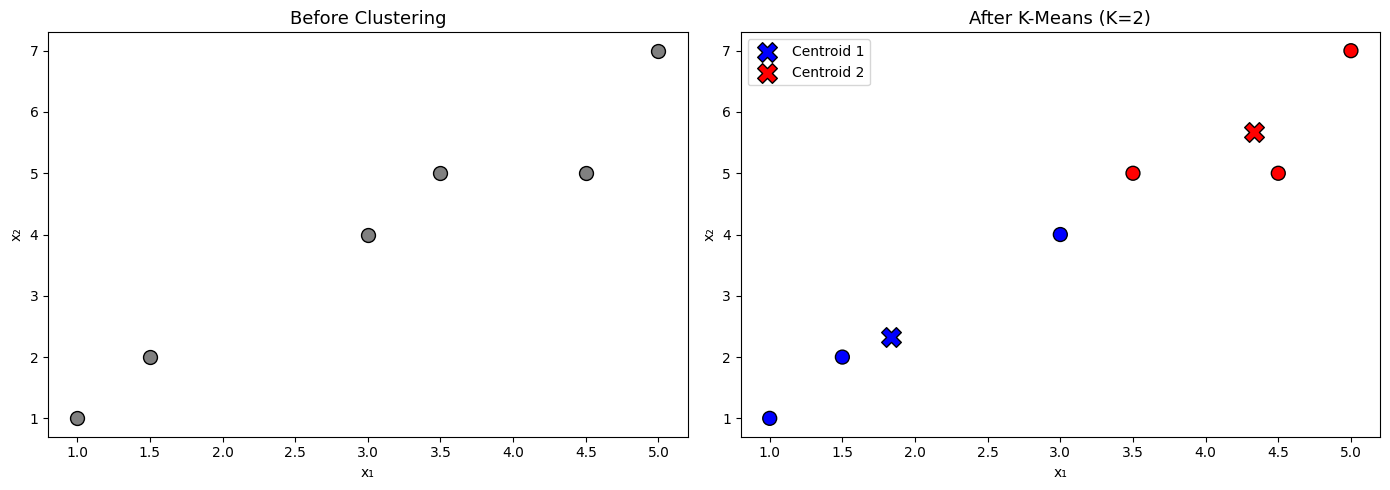

In [72]:
# Visualize the manual clustering result
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before clustering
axes[0].scatter(data_manual[:, 0], data_manual[:, 1], c='gray', s=100, edgecolors='black')
axes[0].set_title("Before Clustering", fontsize=13)
axes[0].set_xlabel("x₁")
axes[0].set_ylabel("x₂")

# After clustering
colors = ['blue' if c == 1 else 'red' for c in clusters_new]
axes[1].scatter(data_manual[:, 0], data_manual[:, 1], c=colors, s=100, edgecolors='black')
axes[1].scatter(*mu1, c='blue', marker='X', s=200, edgecolors='black', label='Centroid 1')
axes[1].scatter(*mu2, c='red', marker='X', s=200, edgecolors='black', label='Centroid 2')
axes[1].set_title("After K-Means (K=2)", fontsize=13)
axes[1].set_xlabel("x₁")
axes[1].set_ylabel("x₂")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Load the Customer Dataset

Now let's apply K-Means to a real-world style dataset: customer segmentation based on income and spending score.

In [54]:
df = pd.read_csv('customer_data.csv')
print("Shape:", df.shape)
df.head(10)

Shape: (70, 3)


,CustomerID,Annual_Income,Spending_Score
0,1,15,39
1,2,16,81
2,3,17,6
3,4,18,77
4,5,19,40
5,6,20,76
6,7,21,6
7,8,23,94
8,9,24,3
9,10,25,72


In [55]:
print("Dataset Info:")
print(df.describe())

Dataset Info:
       CustomerID  Annual_Income  Spending_Score
count   70.000000      70.000000       70.000000
mean    35.500000      60.828571       49.214286
std     20.351085      27.053876       25.657099
min      1.000000      15.000000        3.000000
25%     18.250000      38.250000       30.500000
50%     35.500000      62.000000       50.000000
75%     52.750000      84.500000       71.500000
max     70.000000     104.000000       99.000000


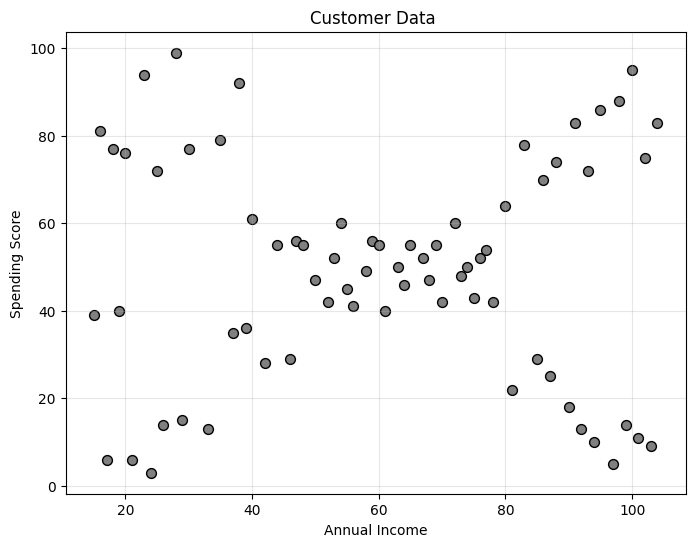

In [56]:
# Visualize the raw data
plt.figure(figsize=(8, 6))
plt.scatter(df['Annual_Income'], df['Spending_Score'], c='gray', edgecolors='black', s=50)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Data ')
plt.grid(True, alpha=0.3)
plt.show()

## 5. Apply K-Means Clustering

In [ ]:
# Select features for clustering
X = df[['Annual_Income', 'Spending_Score']].values

# Apply K-Means with K=5
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

print(f"K-Means with K=5:")
print(f"  Centroids:\n{kmeans.cluster_centers_}")
print(f"  WCSS (Inertia): {kmeans.inertia_:.2f}")
print(f"  Iterations to converge: {kmeans.n_iter_}")
print(f"\n  Cluster sizes: {np.bincount(clusters)}")

K-Means with K=3:
  Centroids:
[[29.         22.        ]
 [77.73333333 49.04444444]
 [31.69230769 74.92307692]]
  WCSS (Inertia): 42390.40
  Iterations to converge: 5

  Cluster sizes: [12 45 13]


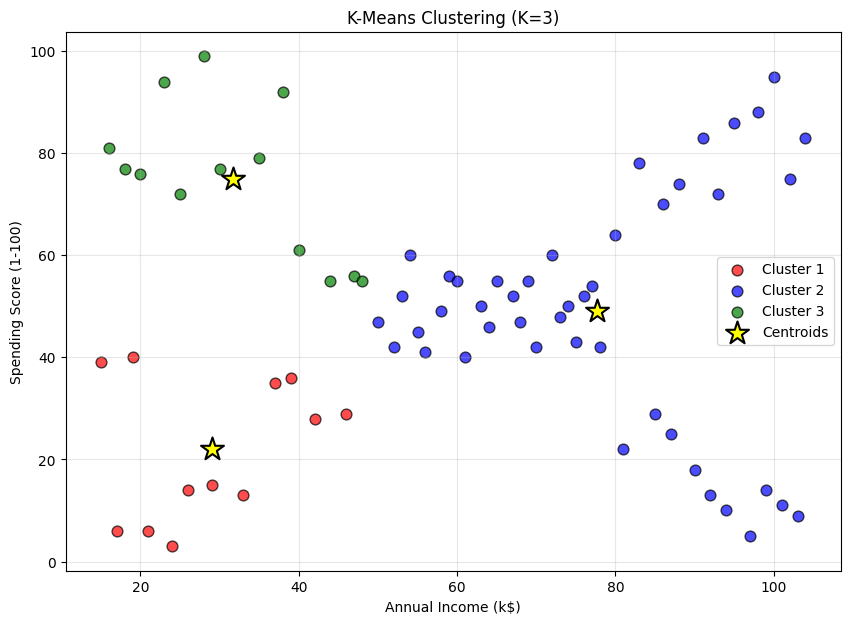

In [ ]:
# Visualize the clusters
plt.figure(figsize=(10, 7))
colors = ['red', 'blue', 'green', 'purple', 'orange']
for i in range(5):
    mask = clusters == i
    plt.scatter(X[mask, 0], X[mask, 1], c=colors[i], label=f'Cluster {i+1}', 
                edgecolors='black', s=60, alpha=0.7)

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='yellow', marker='*', s=300, edgecolors='black', linewidths=1.5,
            label='Centroids', zorder=5)

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('K-Means Clustering (K=5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. The Elbow Method — Finding Optimal K

We run K-Means for different values of K and plot the WCSS (inertia). The "elbow" in the curve suggests the best K.

  K=1: WCSS = 95923.73
  K=2: WCSS = 58285.21
  K=3: WCSS = 42390.40
  K=4: WCSS = 24772.92
  K=5: WCSS = 11083.42
  K=6: WCSS = 8614.74
  K=7: WCSS = 6550.28
  K=8: WCSS = 5707.28
  K=9: WCSS = 4925.08
  K=10: WCSS = 4212.86


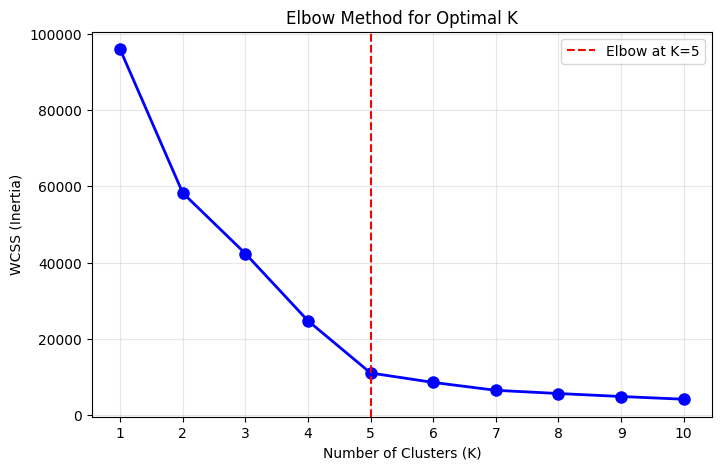

In [78]:
# Elbow Method
wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X)
    wcss.append(km.inertia_)
    print(f"  K={k}: WCSS = {km.inertia_:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal K')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.axvline(x=5, color='red', linestyle='--', label='Elbow at K=5')
plt.legend()
plt.show()


## 7. Comparing Different Values of K

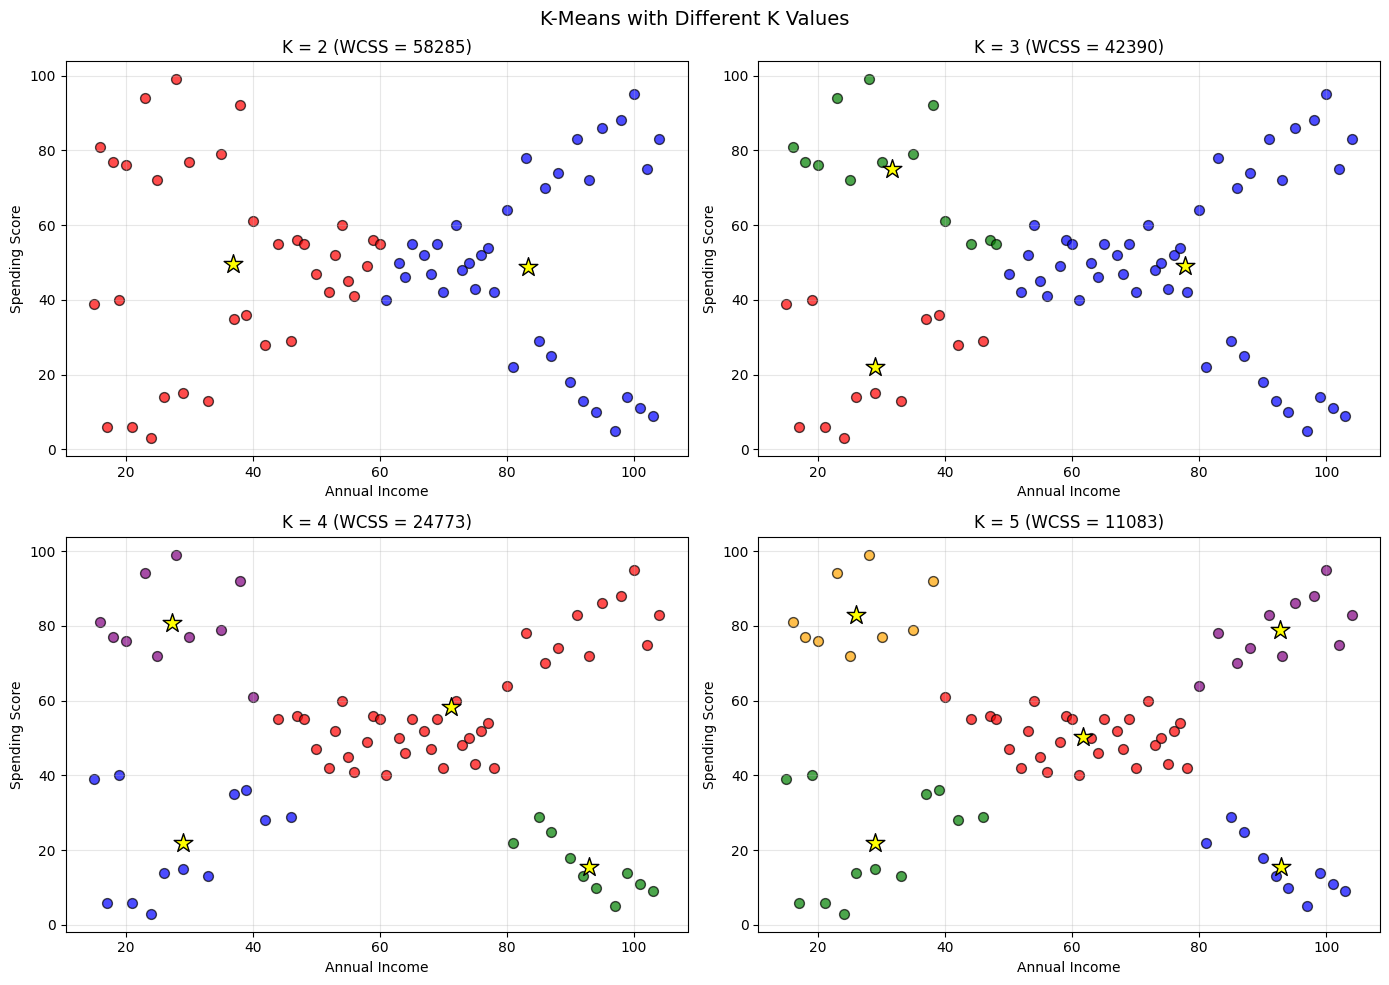

In [79]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
k_values = [2, 3, 4, 5]
colors_list = ['red', 'blue', 'green', 'purple', 'orange']

for idx, k in enumerate(k_values):
    ax = axes[idx // 2, idx % 2]
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    pred = km.fit_predict(X)
    
    for i in range(k):
        mask = pred == i
        ax.scatter(X[mask, 0], X[mask, 1], c=colors_list[i], s=50, alpha=0.7, edgecolors='black')
    
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               c='yellow', marker='*', s=200, edgecolors='black', zorder=5)
    ax.set_title(f'K = {k} (WCSS = {km.inertia_:.0f})')
    ax.set_xlabel('Annual Income')
    ax.set_ylabel('Spending Score')
    ax.grid(True, alpha=0.3)

plt.suptitle('K-Means with Different K Values', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Effect of Initialization

K-Means is sensitive to initial centroid placement. Let's see how `k-means++` vs random initialization compare.

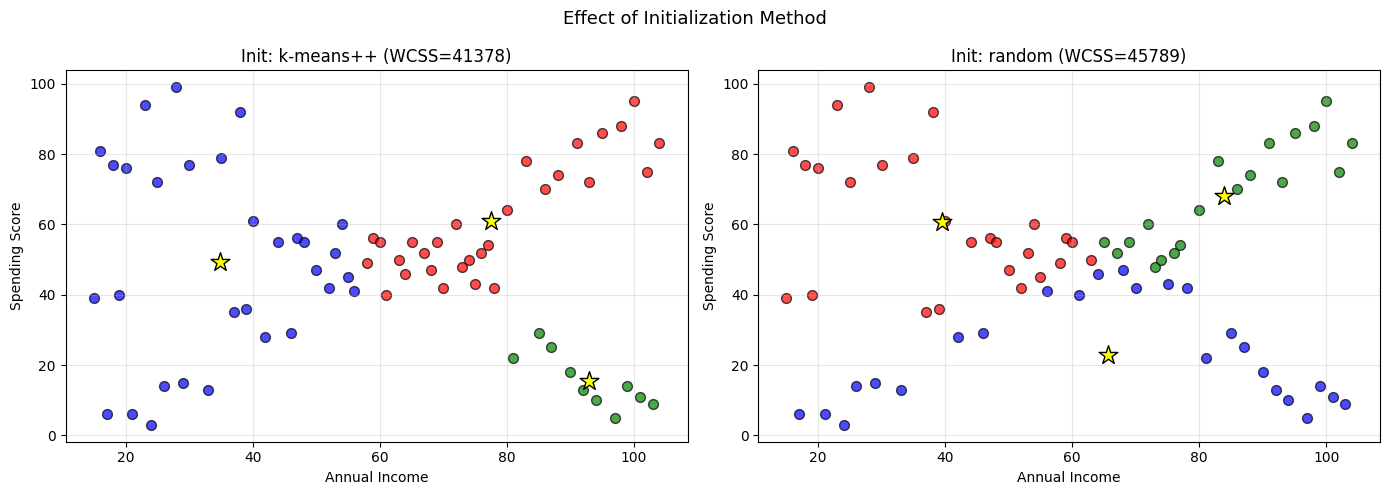

k-means++ generally gives better results by spreading initial centroids apart.


In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
inits = ['k-means++', 'random']

for idx, init_method in enumerate(inits):
    km = KMeans(n_clusters=3, init=init_method, random_state=0, n_init=1)
    pred = km.fit_predict(X)
    
    ax = axes[idx]
    for i in range(3):
        mask = pred == i
        ax.scatter(X[mask, 0], X[mask, 1], c=colors[i], s=50, alpha=0.7, edgecolors='black')
    
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               c='yellow', marker='*', s=200, edgecolors='black', zorder=5)
    ax.set_title(f'Init: {init_method} (WCSS={km.inertia_:.0f})')
    ax.set_xlabel('Annual Income')
    ax.set_ylabel('Spending Score')
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Initialization Method', fontsize=13)
plt.tight_layout()
plt.show()

print("k-means++ generally gives better results by spreading initial centroids apart.")